# Week 03: Characteristics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

# Define Global Plotting Commands

In [2]:
import matplotlib.pyplot as plt

# Label sizes
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.title_fontsize'] = 16
#Axes tick marks
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.minor.width'] = 1.0
plt.rcParams['ytick.minor.width'] = 1.0

# Plotting choices
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.markerscale'] = 3


## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [3]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_4212/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_4212/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

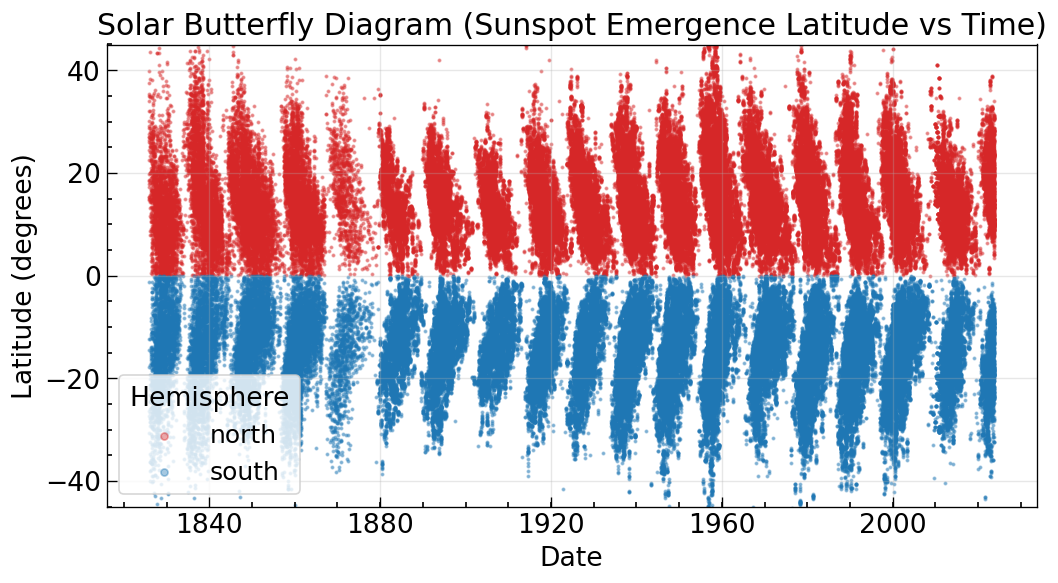

In [4]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:** 
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


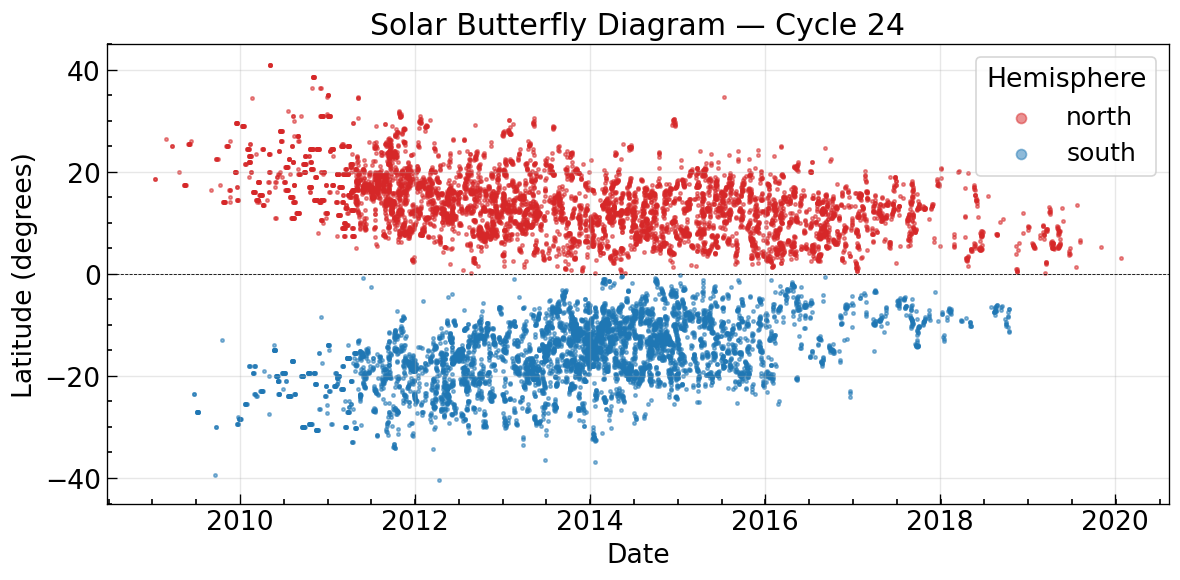

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [5]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_4212/2015835256.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


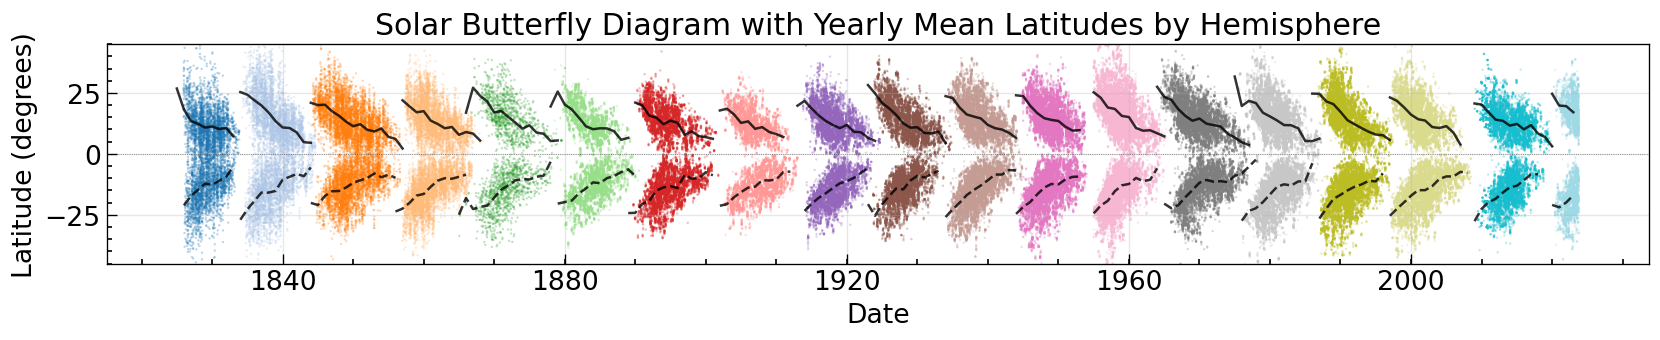

In [6]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2, 
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}", 
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]
    
    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
                linewidth=1.5, linestyle="-", alpha=0.8)
    
    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

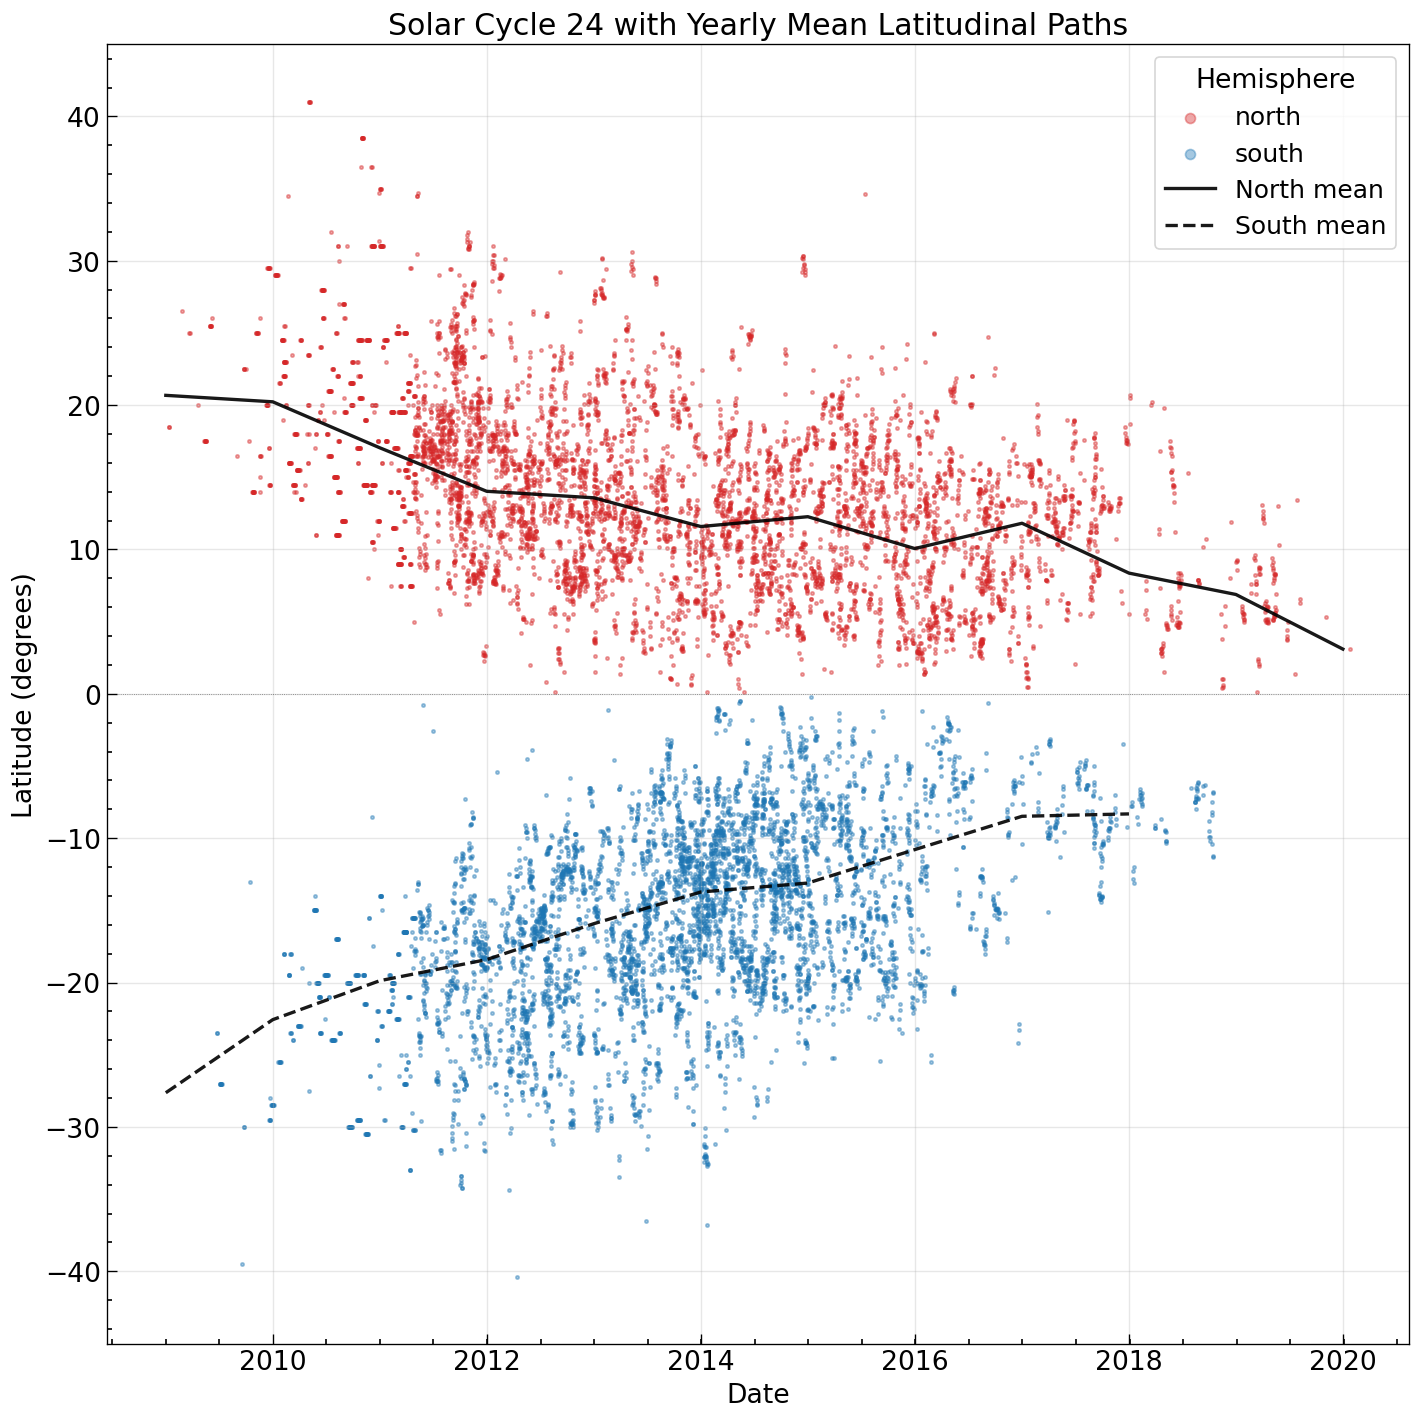

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [7]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


Year 1960 | Hemisphere: north | N = 1656
  Median = 14.0°   Q1 = 8.9°   Q3 = 20.3°   IQR = 11.4°


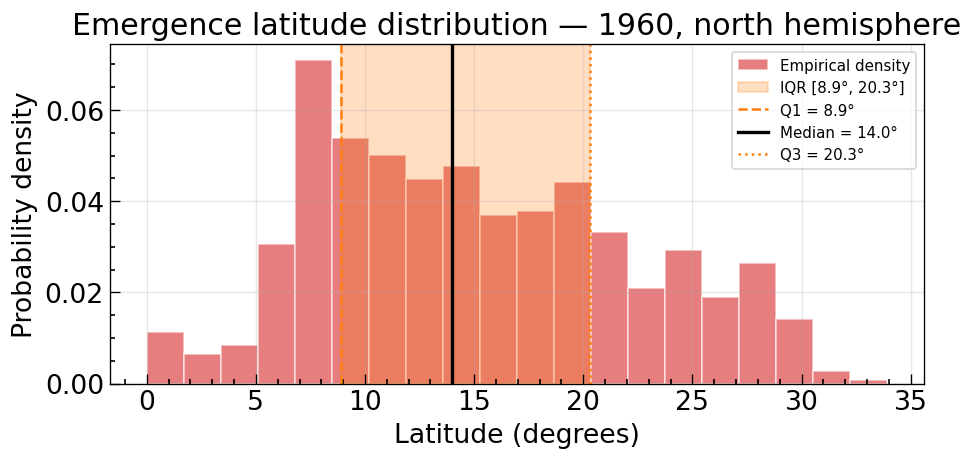

In [8]:
# Task 6: Empirical distribution of emergence latitudes for a single year
import numpy as np

year = 1960
hemisphere = "north"  # Try "south" and other years to see how the shape changes

# Filter to the chosen year and hemisphere
mask = (df["year"] == year) & (df["hemisphere"] == hemisphere)
lats = df.loc[mask, "latitude"].values

# Compute quartiles
q1, median, q3 = np.percentile(lats, [25, 50, 75])
iqr = q3 - q1

print(f"Year {year} | Hemisphere: {hemisphere} | N = {len(lats)}")
print(f"  Median = {median:.1f}°   Q1 = {q1:.1f}°   Q3 = {q3:.1f}°   IQR = {iqr:.1f}°")

fig, ax = plt.subplots(figsize=(8, 4))

# Density-normalised histogram so the y-axis is a probability density
ax.hist(lats, bins=20, density=True, color="tab:red", alpha=0.6, edgecolor="white",
        label="Empirical density")

# Shade the IQR
ax.axvspan(q1, q3, color="tab:orange", alpha=0.25, label=f"IQR [{q1:.1f}°, {q3:.1f}°]")

# Vertical lines for the three quartiles
ax.axvline(q1,     color="tab:orange", linestyle="--", linewidth=1.5, label=f"Q1 = {q1:.1f}°")
ax.axvline(median, color="black",      linestyle="-",  linewidth=2,   label=f"Median = {median:.1f}°")
ax.axvline(q3,     color="tab:orange", linestyle=":",  linewidth=1.5, label=f"Q3 = {q3:.1f}°")

ax.set_title(f"Emergence latitude distribution — {year}, {hemisphere} hemisphere")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Probability density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


Fitted Normal:  μ = 15.07°   σ = 7.26°
  μ = mean emergence latitude  → tracks Spörer's Law (equatorward drift)
  σ = spread around the mean   → width of the butterfly wing


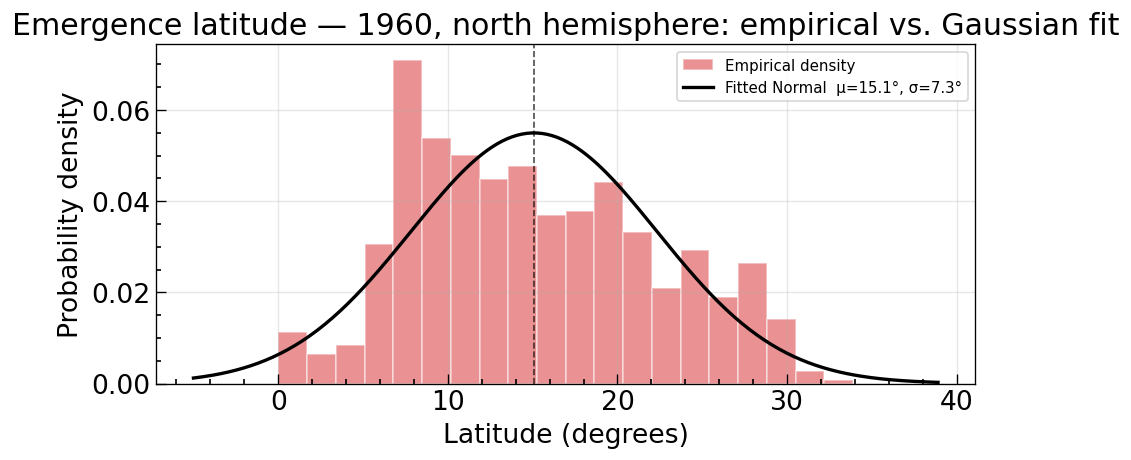

In [9]:
# Task 7: Fit a Normal distribution and overlay on the histogram
from scipy.stats import norm

# Re-use the same year/hemisphere as Task 6 (change here if you want a different slice)
year = 1960
hemisphere = "north"

mask = (df["year"] == year) & (df["hemisphere"] == hemisphere)
lats = df.loc[mask, "latitude"].values

# --- Fit ---
mu, sigma = norm.fit(lats)
print(f"Fitted Normal:  μ = {mu:.2f}°   σ = {sigma:.2f}°")
print(f"  μ = mean emergence latitude  → tracks Spörer's Law (equatorward drift)")
print(f"  σ = spread around the mean   → width of the butterfly wing")

# --- Plot ---
x_grid = np.linspace(lats.min() - 5, lats.max() + 5, 300)

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(lats, bins=20, density=True, color="tab:red", alpha=0.5, edgecolor="white",
        label="Empirical density")

ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color="black", linewidth=2,
        label=f"Fitted Normal  μ={mu:.1f}°, σ={sigma:.1f}°")

ax.axvline(mu, color="black", linestyle="--", linewidth=1, alpha=0.7)

ax.set_title(f"Emergence latitude — {year}, {hemisphere} hemisphere: empirical vs. Gaussian fit")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Probability density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


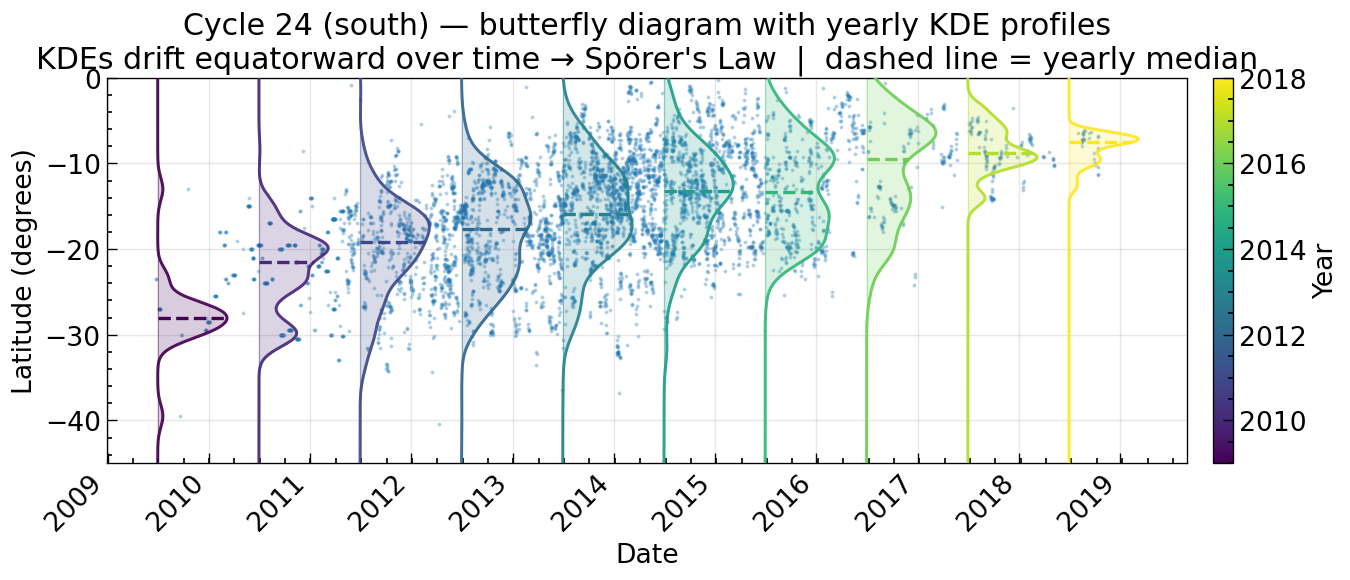

Cycle 24 (south) — yearly median and KDE peak latitudes:
  2009: median = -28.0°   KDE peak = -28.0°
  2010: median = -21.5°   KDE peak = -19.9°
  2011: median = -19.2°   KDE peak = -17.5°
  2012: median = -17.7°   KDE peak = -16.3°
  2013: median = -15.9°   KDE peak = -17.3°
  2014: median = -13.2°   KDE peak = -12.5°
  2015: median = -13.3°   KDE peak = -9.3°
  2016: median = -9.5°   KDE peak = -6.5°
  2017: median = -8.8°   KDE peak = -9.3°
  2018: median = -7.5°   KDE peak = -7.2°


In [10]:
# Task 8: KDE evolution through a solar cycle — butterfly diagram + per-year KDE profiles
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde

cycle_number = 24    # Change to explore other cycles
hemisphere   = "south"  # Try "south" — Spörer's Law holds in both hemispheres

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

years_in_cycle = sorted(df_cyc_hemi["year"].unique())
n_years = len(years_in_cycle)

# Colour map: early years → purple, late years → yellow (viridis is perceptually uniform
# and appropriate for a strictly increasing quantity like time)
cmap = plt.get_cmap("viridis", n_years)

# Latitude grid for evaluating KDEs (stay within the Spörer zone)
lat_grid = np.linspace(0, 45, 300) if hemisphere == "north" else np.linspace(-45, 0, 300)

# How wide (in days) should the tallest KDE peak be?
# ~250 days ≈ 2/3 of a year — wide enough to read, narrow enough not to overlap badly
kde_width_days = 250

fig, ax = plt.subplots(figsize=(12, 5))

# --- Background: butterfly diagram scatter ---
scatter_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=scatter_color, alpha=0.25, zorder=1, label="Sunspot groups")

# --- Foreground: per-year KDE profiles drawn vertically ---
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:          # skip years with too few observations
        continue

    kde = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde(lat_grid)

    # Normalise so the peak reaches kde_width_days on the x-axis
    kde_scaled = kde_vals / kde_vals.max() * kde_width_days

    # Anchor each profile at July 1 of that year
    center = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_scaled]
    x_anchor = [center] * len(lat_grid)

    color = cmap(i)
    ax.plot(x_curve, lat_grid, color=color, linewidth=1.8, alpha=0.9, zorder=3)
    ax.fill_betweenx(lat_grid, x_anchor, x_curve,
                     color=color, alpha=0.20, zorder=2)
    # Thin vertical baseline at the anchor date
    ax.axvline(center, color=color, linewidth=0.5, alpha=0.4, zorder=1)

    # Horizontal line at the yearly median latitude, extending to the KDE curve edge
    median_lat = np.median(yr_lats)
    kde_at_median = float(kde(np.array([median_lat]))[0])
    kde_at_median_scaled = kde_at_median / kde_vals.max() * kde_width_days
    x_median_end = center + pd.Timedelta(days=kde_at_median_scaled)
    ax.plot([center, x_median_end], [median_lat, median_lat],
            color=color, linewidth=2, linestyle="--", alpha=1.0, zorder=4)

# --- Colour bar (time axis) ---
sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=years_in_cycle[0],
                                               vmax=years_in_cycle[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Year")

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — butterfly diagram with yearly KDE profiles\n"
    f"KDEs drift equatorward over time → Spörer's Law  |  dashed line = yearly median"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Numeric summary: KDE peak latitude per year (tracks Spörer drift) ---
print(f"Cycle {cycle_number} ({hemisphere}) — yearly median and KDE peak latitudes:")
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde = gaussian_kde(yr_lats, bw_method=0.3)
    peak_lat   = lat_grid[np.argmax(kde(lat_grid))]
    median_lat = np.median(yr_lats)
    print(f"  {int(yr)}: median = {median_lat:.1f}°   KDE peak = {peak_lat:.1f}°")

---
## Week 03 Exercises: From Snapshots to a Parametric Wing Model

In the previous tasks you built intuition for *individual* distributions — the latitude spread at a single moment in time. Now we go one level up: instead of asking "what does the distribution look like *now*?", we ask **"how does the distribution evolve over an entire cycle?"**

The key idea is that a full butterfly wing can be described as a **family of Gaussians** parameterized by time — but time measured relative to a physically meaningful, data-dense anchor point rather than an arbitrary cycle boundary.

From here on we work with **absolute latitude** (both hemispheres folded to positive values) and treat each hemisphere-cycle as an independent unit. This doubles our sample size and makes the analysis symmetric.

The three exercises below build a parametric model step by step.

## 9) Exercise: Standardizing Time to the 15° latitude Crossing

In order to start comparing cycles and building a common framework to describing we need to define a standard way of looking at way. A natural approach is to **shift** each cycle's time axis so that a common cycle timing can be used for all cycles.

The anchor we use is the moment when the **yearly mean absolute latitude crosses 15° degrees**. 

The resulting time coordinate τ = date − t₀ is in physical units (years). 

**Task:**
- Add an `abs_latitude` column to `df` (absolute value of latitude). All subsequent analysis uses this column.
- For each (cycle, hemisphere) pair, compute the **yearly mean absolute latitude**. Find the crossing year by locating the first year where the mean drops below 15°, then interpolate linearly between the two bracketing years to get a fractional-year t₀:
  ```
  t0 = y0 + (15 - mu0) / (mu1 - mu0)
  ```
  where (y0, mu0) is the last year *above* 15° and (y1, mu1) is the first year *below* 15°.
- Add a `tau` column to `df`: for each row, `tau = (date.dt.year + date.dt.dayofyear / 365.25) − t0`, using the t₀ for that row's (cycle, hemisphere).
  - *Hint:* Build a lookup dict `{(cycle, hemi): t0}` first, then map it onto `df`.
- Plot absolute latitude vs. τ for **all** hemisphere-cycles on a single axis, colored by cycle number.
- **Discussion:** Look at the region τ > 0 (post-crossing, decaying phase). Do the wings from different cycles align with each other? Now look at τ < 0 (rising phase). Is the alignment as tight? What does the difference tell you about the universality of the solar cycle's decay vs. its rise?


In [48]:
# Put your code for Task 9 here

df["abs_latitude"] = df["latitude"].abs()

# Compute the yearly mean of the absolute latitude for each (cyle, hemisphere) pair
yearly_mean_abs_lat = df.groupby(["CYCLE", "hemisphere", "year"])["abs_latitude"].mean().reset_index()
yearly_mean_abs_lat = yearly_mean_abs_lat.sort_values('year')

# Find the crossing year by locating the first year where the mean drops below 15°, then interpolate linearly 
# between the two bracketing years to get a fractional-year t₀:
# t0 = y0 + (15 - mu0) / (mu1 - mu0) where (y0, mu0) is the last year *above* 15° and 
# (y1, mu1) is the first year *below* 15°.
def find_crossing_year(group, latitude_threshold=15):
    
    for row in range(len(group)-1):
        y0 = group.iloc[row]["year"]
        mu0 = group.iloc[row]["abs_latitude"]
        mu1 = group.iloc[row+1]["abs_latitude"]
        
        if mu0 >= latitude_threshold and mu1 < latitude_threshold:
            t0 = y0 + (latitude_threshold - mu0) / (mu1 - mu0)
            return t0
    
        
crossing_dict = yearly_mean_abs_lat.groupby(["CYCLE", "hemisphere"]).apply(find_crossing_year).dropna().to_dict()

# add a `tau` column to `df`: for each row, `tau = (date.dt.year + date.dt.dayofyear / 365.25) − t0`,
# using the t₀ for that row's (cycle, hemisphere).
df['tau'] = (df["date"].dt.year + df["date"].dt.dayofyear / 365.25) - df.apply(lambda row: crossing_dict.get((row["CYCLE"], row["hemisphere"])), axis=1)

# drop cycles where data is missing
df = df.dropna(subset=['CYCLE'])



/tmp/ipykernel_4212/316754523.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  crossing_dict = yearly_mean_abs_lat.groupby(["CYCLE", "hemisphere"]).apply(find_crossing_year).dropna().to_dict()


/tmp/ipykernel_4212/3669675876.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


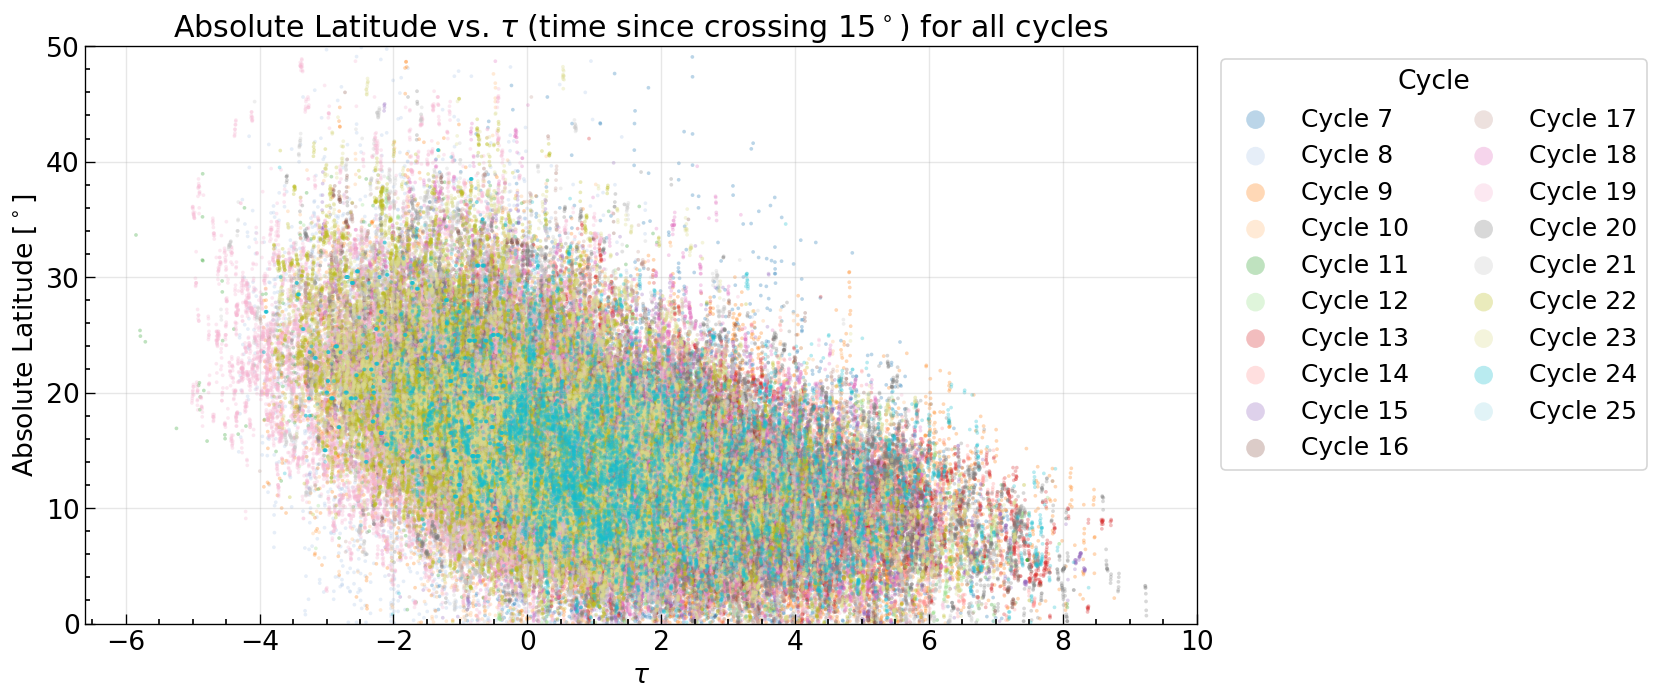

In [62]:
# Plot absolute latitude vs. τ for **all** hemisphere-cycles on a single axis, colored by cycle number.
# color scheme
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}


fig, ax = plt.subplots(figsize=(14, 6))
# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["tau"], df_cyc["abs_latitude"], s=5, 
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}", 
               alpha=0.3, edgecolors="none")

ax.set_title(r"Absolute Latitude vs. $\tau$ (time since crossing 15$^\circ$) for all cycles")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"Absolute Latitude [$^\circ$]")
ax.set_ylim(0, 50)
plt.legend(markerscale=5, bbox_to_anchor=(1.01, 1), loc='upper left', ncol=2, title='Cycle')
plt.tight_layout()
plt.show()

**Discussion:** Look at the region τ > 0 (post-crossing, decaying phase). Do the wings from different cycles align with each other? Now look at τ < 0 (rising phase). Is the alignment as tight? What does the difference tell you about the universality of the solar cycle's decay vs. its rise?

--

Answer: At $\tau > 0$, the wings of the different cycles appear to align well. They are clustered at low latitudes, which intuitively matches the decaying phase of each cycle. At $\tau < 0$, the alignment is much looser as sunspots are seen at a wide range of latitudes from ~$50^\circ$ to ~$0^\circ$. From this analysis, I find that a crossing at $15^\circ$ seems like a universal ground truth for when the solar cycle in both hemispheres appears to decay. 

---------------------------

## 10) Exercise: Fitting the mean path μ(τ) of a Single Hemisphere-Cycle

In Task 7 you fitted one Gaussian per *year*. Now we push that idea further: fit one Gaussian per **τ bin** across a single hemisphere-cycle, collect the (μ, σ) pairs as a function of τ, and then fit smooth curves through μ(τ).

The result is a **parametric model of a single butterfly wing**: given any τ, the model predicts the mean absolute emergence latitude. Later we will look at the spread.

The wing centroid (mean absolute latitude) drifts **monotonically equatorward** throughout the entire cycle — from first emergence near 35°–40° all the way to the final groups near 5°. This means a single smooth function can describe the full trajectory.

The appropriate model is an **exponential decay**:

$$\mu(\tau) = a \cdot \exp\!\left(-\frac{\tau}{b}\right)$$

```python
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)
```

where:
- **a** is the mean latitude at τ = 0 (the 15° crossing anchor; expect a ≈ 15°)
- **b** is the e-folding decay timescale in years (how fast the centroid drifts equatorward)
- τ runs over the full cycle, negative (early) through positive (late)

**Task:**
- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere). Filter `df` to that pair.
- Divide the τ axis into `N_bins = 20` equal-width bins spanning the full τ range. For each bin, fit a Gaussian to `abs_latitude` using `scipy.stats.norm.fit`. Extract μ and σ. Skip bins with fewer than 10 observations.
- Use `scipy.optimize.curve_fit` with `exp_decay` to fit μ(τ). Overlay the fitted curve on a scatter plot of (τ bin center, μ).
- **Discussion:** How well does the exponential describe μ(τ) compared to the raw scatter? 

In [83]:
# Put your code for Task 10 here
from scipy.optimize import curve_fit

# choose a particular cycle and hemisphere and filter the df
chosen_cycle = 19
chosen_hemisphere = "north"
df_chosen = df[(df["CYCLE"] == chosen_cycle) & (df["hemisphere"] == chosen_hemisphere)].copy()

Nbins = 20
bins = np.linspace(df_chosen["tau"].min(), df_chosen["tau"].max(), Nbins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

mu_vals, sigma_vals = [], []

for i in range(Nbins):
    bin_mask = (df_chosen["tau"] >= bins[i]) & (df_chosen["tau"] < bins[i+1])
    lats_in_bin = df_chosen.loc[bin_mask, "abs_latitude"].values
    
    if len(lats_in_bin) < 10:
        mu_vals.append(np.nan)
        sigma_vals.append(np.nan)
        continue
    
    mu, sigma = norm.fit(lats_in_bin)
    mu_vals.append(mu)
    sigma_vals.append(sigma)


def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)


popt, pcov = curve_fit(exp_decay,bin_centers, mu_vals)

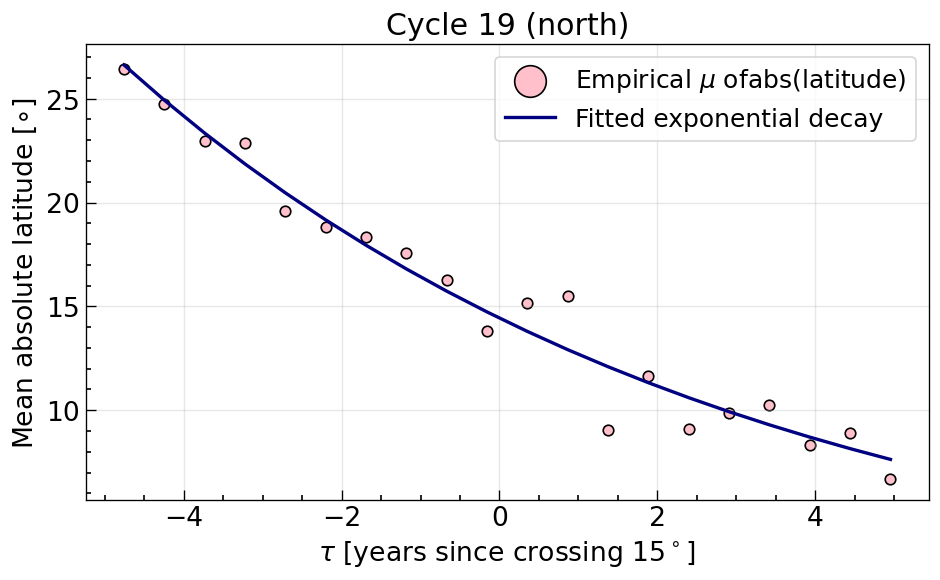

In [85]:
plt.figure(figsize=(8, 5))

plt.scatter(bin_centers, mu_vals, label=r"Empirical $\mu$ ofabs(latitude)", color="pink", edgecolor='k', s=40)
plt.plot(bin_centers, exp_decay(bin_centers, *popt), label="Fitted exponential decay", color="navy", linewidth=2)
plt.legend(loc="upper right")
plt.title(rf"Cycle {chosen_cycle} ({chosen_hemisphere})")
plt.xlabel(r"$\tau$ [years since crossing $15^\circ$]")
plt.ylabel(r"Mean absolute latitude [$\circ$]")
plt.tight_layout()
plt.show()

**Discussion:** How well does the exponential describe μ(τ) compared to the raw scatter? 

----

Answer: The exponential fit describes $\mu(\tau)$ extremely well alongside the scatter for the northern hemisphere of Cycle 19.

-----------------------

## 11) Exercise: Fitting the spread σ(τ) a Single Hemisphere-Cycle

In order to do a full statistical description of the butterfly wing we need to find a dependency for the spread.   This is harder than the mean path.   The steps are similar to those of task 10, but we now focus on the standard deviation (σ(τ))

**Task:**
- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere). Filter `df` to that pair.
- Divide the τ axis into `N_bins = 20` equal-width bins spanning the full τ range. For each bin, fit a Gaussian to `abs_latitude` using `scipy.stats.norm.fit`. Extract μ and σ. Skip bins with fewer than 10 observations.
- Plot the standard deviation (σ) as a function of tau.
- Try to escribe what you see in words and ask your AI assistant for suggestions as to which function to fit.
- Fit it.
- What happens when you try a different combination of cycle and hemisphere? does it still work?

In [ ]:
# Put your code for Task 11 here


# choose a particular cycle and hemisphere and filter the df
chosen_cycle = 19
chosen_hemisphere = "north"
df_chosen = df[(df["CYCLE"] == chosen_cycle) & (df["hemisphere"] == chosen_hemisphere)].copy()

Nbins = 20
bins = np.linspace(df_chosen["tau"].min(), df_chosen["tau"].max(), Nbins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

mu_vals, sigma_vals = [], []

for i in range(Nbins):
    bin_mask = (df_chosen["tau"] >= bins[i]) & (df_chosen["tau"] < bins[i+1])
    lats_in_bin = df_chosen.loc[bin_mask, "abs_latitude"].values
    
    if len(lats_in_bin) < 10:
        mu_vals.append(np.nan)
        sigma_vals.append(np.nan)
        continue
    
    mu, sigma = norm.fit(lats_in_bin)
    mu_vals.append(mu)
    sigma_vals.append(sigma)
    
    

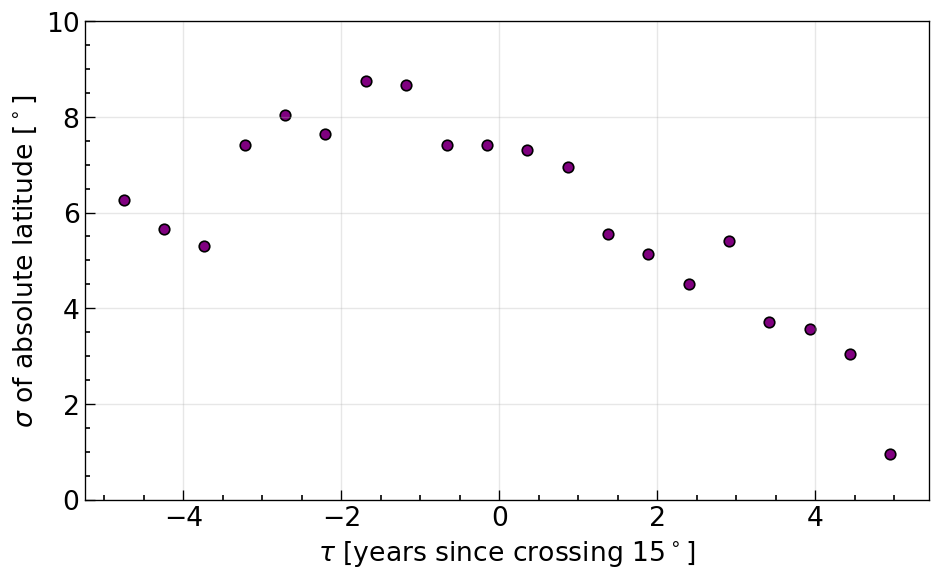

In [90]:
plt.figure(figsize=(8, 5))
plt.scatter(bin_centers, sigma_vals, label=r"Empirical $\sigma$ of abs(latitude)", color="purple", edgecolor='k', s=40)
plt.xlabel(r"$\tau$ [years since crossing $15^\circ$]")
plt.ylabel(r"$\sigma$ of absolute latitude [$^\circ$]")
plt.ylim(0,10)
plt.tight_layout()
plt.show()

In [ ]:
# 

## 12) Exercise: Ensemble Variability and the Mean Butterfly Template

One hemisphere-cycle's μ(τ) fit is one realization. The *spread* across many realizations is the scientific signal — it encodes cycle-to-cycle and hemisphere-to-hemisphere variability, and it defines what a generative model eventually needs to reproduce.

**Task:**
- Repeat the Task 10 and Task 11 pipelines for **all** hemisphere-cycles with sufficient data (e.g. cycles 12–24, both hemispheres → up to ~26 fits). For each, store the best-fit (a, b) pair for μ(τ) and σ(τ).
- Evaluate every fitted exponential on a common τ grid: `tau_grid = np.linspace(-6, 6, 300)`. Collect results into two arrays of shape `(n_hemicycles, 300)` for μ and σ.
- On a single figure with **two panels** (top: μ(τ), bottom: σ(τ)), plot each hemisphere-cycle as a thin colored line. Overlay the **pointwise mean** and **±1σ envelope** in black.
  - *Hint:* Use `np.nanmean` and `np.nanstd` along axis 0 to handle hemisphere-cycles that don't cover the full τ grid.
- As a separate figure, make a **scatter plot of the fitted (a, b) parameters** across all hemisphere-cycles, colored by cycle number. This is the parameter space of your model.

In [ ]:
# Put your code for Task 12 here